In [1]:
%load_ext autoreload
%autoreload 2

## 1. Imports

In [2]:
import os
import sys

sys.path.append("..")

import random

import numpy as np
import torch
from torchmin import Minimizer
from tqdm import tqdm

import wandb
from src.embeddings.base import Embeddings
from src.embeddings.utils import (
    foscttm,
    get_vectors_and_labels,
    load_dictionary_words,
    make_dictionary,
    restrict,
)
from src.models.light_gcot import LightGCOT
from src.samplers.from_dataset import DatasetSampler
from src.utils.paired import get_paired_with_labels_sampler
from src.utils.plotting.distributions import get_transport_plot_pca, pca
from src.utils.plotting.parameters import (
    plot_A_parameters,
    plot_B_parameters,
    plot_Z_parameters,
)
from src.utils.train import update_average

In [3]:
device = torch.device(f"cuda:{torch.cuda.current_device()}" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [4]:
# torch.set_default_device(device)
dtype = torch.float64
torch.torch.set_default_dtype(dtype)

## 2. Config

In [5]:
X_DIM = 30
Y_DIM = 30

OUTPUT_SEED = 42

N_POTENTIALS = 25
M_POTENTIALS = 25
EPSILON = 1.0
INIT_BY_SAMPLES = True
A_DIAGONAL_INIT = 0.1

BATCH_SIZE = 128
SAMPLING_BATCH_SIZE = 128

D_GRADIENT_MAX_NORM = float("inf")

M_X_UNPAIRED_SAMPLES = 200000
N_Y_UNPAIRED_SAMPLES = 200000
L_PAIRED_SAMPLES = 10872

PLOT_EVERY = 100
MAX_STEPS = 1000
CONTINUE = -1

EXP_COST = "MLP_text"

EMA_UPDATE = False

SOURCE_LANG = "en"
TARGET_LANG = "fr"

METHOD = "l-bfgs"
OPT_MAX_ITER = 200
LR = 3e-4

In [6]:
torch.manual_seed(OUTPUT_SEED)
np.random.seed(OUTPUT_SEED)
random.seed(OUTPUT_SEED)

In [7]:
EXP_META_INFO = ""
EXP_NAME = (
    "Light-GCOT_Word_Alignment_"
    + f"X_DIM_{X_DIM}_"
    + f"Y_DIM_{Y_DIM}_"
    + f"N_{N_POTENTIALS}_"
    + f"M_{M_POTENTIALS}_"
    + f"M_X_UNPAIRED_{M_X_UNPAIRED_SAMPLES}_"
    + f"N_Y_UNPAIRED_{N_Y_UNPAIRED_SAMPLES}_"
    + f"L_PAIRED_{L_PAIRED_SAMPLES}_"
    + f"SOURCE_LANG_{SOURCE_LANG}_"
    + f"TARGET_LANG_{TARGET_LANG}_"
    + f"METHOD_{METHOD}_"
    + f"OPT_MAX_ITER_{OPT_MAX_ITER}_"
    + f"LR_{LR}_"
    + EXP_META_INFO
)
OUTPUT_PATH = "../checkpoints/{}".format(EXP_NAME)

config = dict(
    X_DIM=X_DIM,
    Y_DIM=Y_DIM,
    BATCH_SIZE=BATCH_SIZE,
    N_POTENTIALS=N_POTENTIALS,
    M_POTENTIALS=M_POTENTIALS,
    INIT_BY_SAMPLES=INIT_BY_SAMPLES,
    A_DIAGONAL_INIT=A_DIAGONAL_INIT,
    M_X_UNPAIRED_SAMPLES=M_X_UNPAIRED_SAMPLES,
    N_Y_UNPAIRED_SAMPELS=N_Y_UNPAIRED_SAMPLES,
    L_PAIRED_SAMPLES=L_PAIRED_SAMPLES,
    SOURCE_LANG=SOURCE_LANG,
    TARGET_LANG=TARGET_LANG,
    METHOD=METHOD,
    OPT_MAX_ITER=OPT_MAX_ITER,
    LR=LR,
)

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

## 3. Create data and samplers

In [8]:
emb_src = Embeddings.from_file(f"./datasets/MUSE/embeddings/{SOURCE_LANG}.vec")
emb_tgt = Embeddings.from_file(f"./datasets/MUSE/embeddings/{TARGET_LANG}.vec")

In [9]:
if X_DIM != 300:
    emb_src.vectors = pca(emb_src.vectors, X_DIM)
if Y_DIM != 300:
    emb_tgt.vectors = pca(emb_tgt.vectors, Y_DIM)
# emb_src.vectors = pca(emb_src.vectors, X_DIM)
# emb_tgt.vectors = pca(emb_tgt.vectors, Y_DIM)

In [10]:
emb_src.i2w, emb_tgt.i2w = load_dictionary_words(
    f"./datasets/MUSE/dictionaries/{SOURCE_LANG}-{TARGET_LANG}-train.txt"
)
dictionary = make_dictionary(emb_src.i2w, emb_tgt.i2w)

In [11]:
emb_src_restriced = restrict(emb_src, set(emb_src.i2w), reset_index=True)
emb_tgt_restriced = restrict(emb_tgt, set(emb_tgt.i2w), reset_index=True)

In [12]:
X_paired_train, X_ind_paired_train, Y_paired_train, Y_ind_paired_train = get_vectors_and_labels(
    emb_src, emb_src.i2w, emb_tgt, emb_tgt.i2w, emb_src.vectors.device
)

In [13]:
# X_paired_train, X_ind_paired_train = get_vectors_and_labels(emb_src_restriced, emb_src.i2w, emb_src.vectors.device)
# Y_paired_train, Y_ind_paired_train = get_vectors_and_labels(emb_tgt_restriced, [dictionary[key][0] for key in emb_src.i2w], emb_tgt.vectors.device)

In [14]:
pd_train_sampler = get_paired_with_labels_sampler(
    X_paired_train, X_ind_paired_train, Y_paired_train, Y_ind_paired_train, BATCH_SIZE, L_PAIRED_SAMPLES, device
)

In [15]:
if M_X_UNPAIRED_SAMPLES > 0:
    ind = random.choices(range(len(emb_src.w2i)), k=M_X_UNPAIRED_SAMPLES)
    source_data = restrict(emb_src, set(np.array(list(emb_src.w2i.keys()))[ind]), reset_index=True)
    usd_sampler = DatasetSampler(source_data.vectors, device=device) # usd - unpaired source data
else:
    usd_sampler = DatasetSampler(X_paired_train, device=device)

if N_Y_UNPAIRED_SAMPLES > 0:
    ind = random.choices(range(len(emb_tgt.vectors)), k=N_Y_UNPAIRED_SAMPLES)
    target_data = restrict(emb_tgt, set(np.array(list(emb_tgt.w2i.keys()))[ind]), reset_index=True)
    utd_sampler = DatasetSampler(target_data.vectors, device=device) # utd - unpaired target data
else:
    utd_sampler = DatasetSampler(Y_paired_train, device=device)

In [16]:
src_i2w_test, tgt_i2w_test = load_dictionary_words(
    f"./datasets/MUSE/dictionaries/{SOURCE_LANG}-{TARGET_LANG}-test.txt"
)

In [17]:
X_paired_test, X_ind_paired_test, Y_paired_test, Y_ind_paired_test = get_vectors_and_labels(
    emb_src, src_i2w_test, emb_tgt, tgt_i2w_test, emb_src.vectors.device
)

In [18]:
pd_test_sampler = get_paired_with_labels_sampler(
    X_paired_test, X_ind_paired_test, Y_paired_test, Y_ind_paired_test, BATCH_SIZE, len(X_paired_test), device
)

## 4. Model initialization

In [19]:
D = LightGCOT(
    x_dim=X_DIM,
    y_dim=Y_DIM,
    n_potentials=N_POTENTIALS,
    m_potentials=M_POTENTIALS,
    epsilon=EPSILON,
    sampling_batch_size=SAMPLING_BATCH_SIZE,
    A_diagonal_init=A_DIAGONAL_INIT,
    cost_function=EXP_COST,
).to(dtype).to(device)

if INIT_BY_SAMPLES:
    D.init_a_by_samples(usd_sampler.sample(N_POTENTIALS))

In [20]:
second_order_methods = {'l-bfgs', 'cg', 'newton-cg'}

In [21]:
if METHOD in second_order_methods:
    optimizer = Minimizer(D.parameters(), method=METHOD, max_iter=OPT_MAX_ITER, disp=0)
else:
    optimizer_kwargs = {"params": D.parameters(), "lr": LR}
    optimizer = getattr(torch.optim, METHOD)(**optimizer_kwargs)

In [29]:
# For EMA update
if EMA_UPDATE:
    D_copy = LightGCOT(
        x_dim=X_DIM,
        y_dim=Y_DIM,
        n_potentials=N_POTENTIALS,
        m_potentials=M_POTENTIALS,
        epsilon=EPSILON,
        sampling_batch_size=SAMPLING_BATCH_SIZE,
        A_diagonal_init=A_DIAGONAL_INIT,
        cost_function=EXP_COST,
    ).to(dtype).to(device)

## 5. Model training

In [23]:
num_starting_points = 3
starting_points = usd_sampler.sample(num_starting_points)

In [24]:
num_starting_points_paired = 3
starting_points_paired, _, ending_points_paired, _ = pd_train_sampler.sample(num_starting_points_paired)

D gradient norm,▁
D loss,▁
D paired loss,▁
D unpaired loss,▁
FOSCTTM,▁
Test batched mean cosine similarity,▁
D gradient norm,1651.56218
D loss,-1175.56571
D paired loss,-1754.31127
D unpaired loss,578.74556
FOSCTTM,0.4659


  0%|                                                                                                                     | 0/1000 [00:03<?, ?it/s]


AttributeError: 'builtin_function_or_method' object has no attribute 'detach'

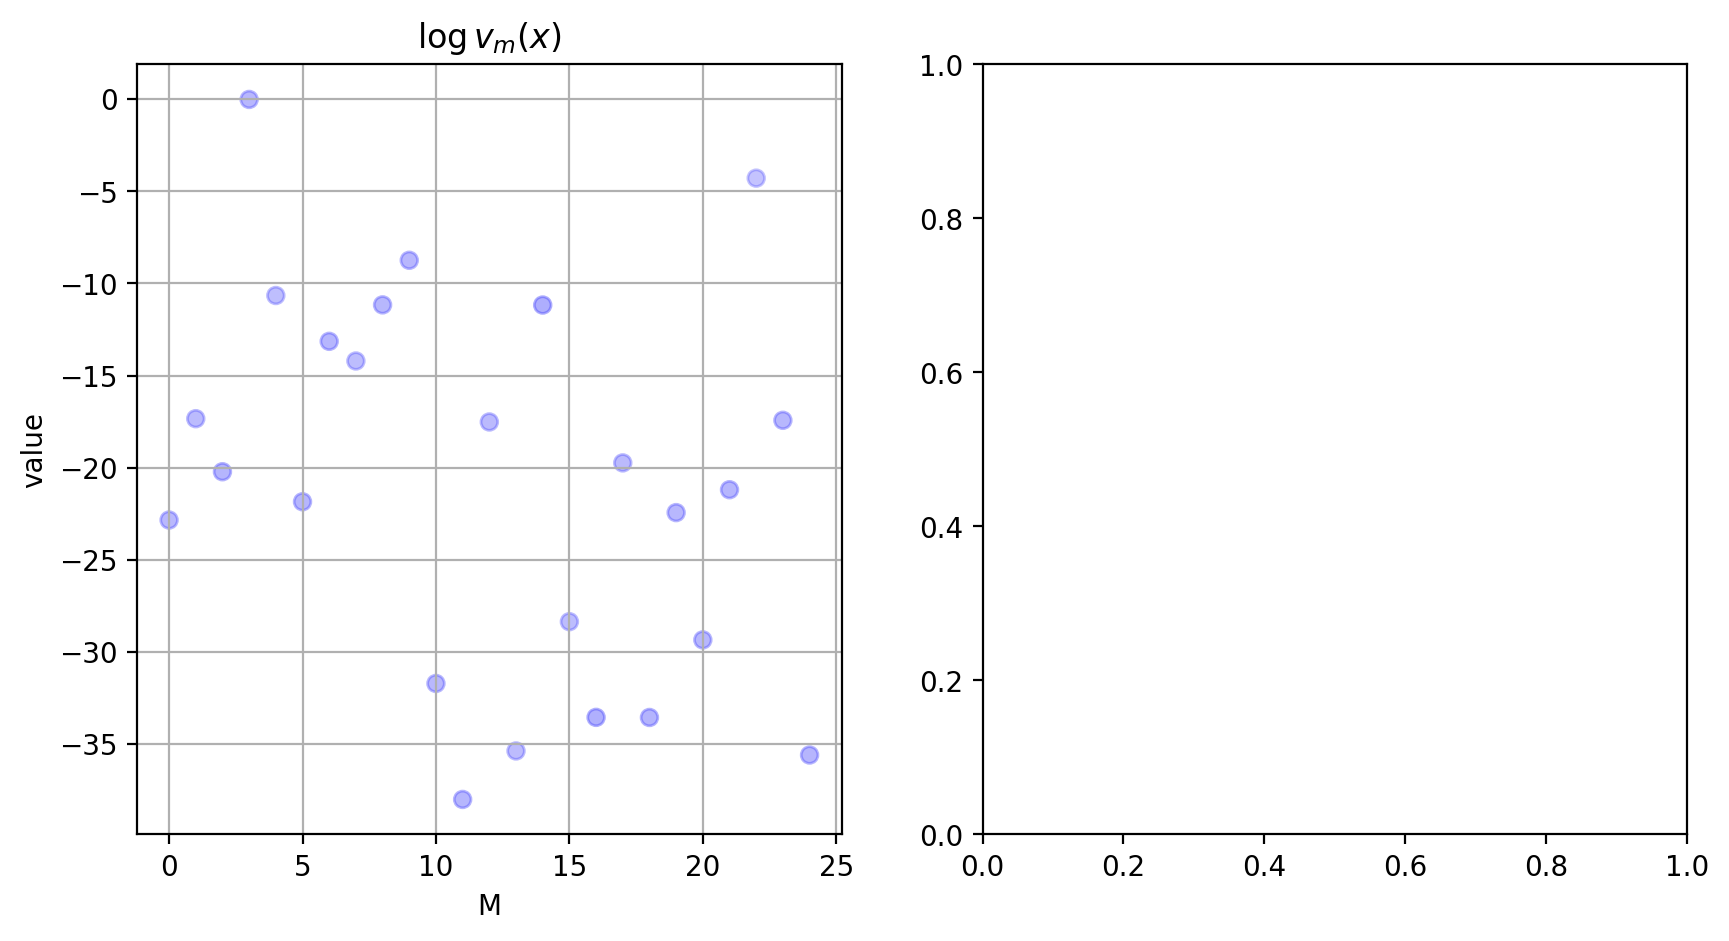

In [25]:
wandb.init(name=EXP_NAME, config=config)

for step in tqdm(range(CONTINUE + 1, MAX_STEPS)):
    X = usd_sampler.sample(BATCH_SIZE)
    Y = utd_sampler.sample(BATCH_SIZE)
    X_paired, _, Y_paired, _ = pd_train_sampler.sample(BATCH_SIZE)

    def closure():
        optimizer.zero_grad()
        
        D_loss_unpaired = D.compute_unpaired_loss(X, Y)
        D_loss_paired = D.compute_paired_loss(X_paired, Y_paired)

        D_loss = D_loss_unpaired + D_loss_paired
        # D_loss.backward()
        
        return D_loss

    if METHOD in second_order_methods:
        optimizer.step(closure)
    else:
        D_loss = closure()
        D_loss.backward()
        optimizer.step()

    D_loss_unpaired = D.compute_unpaired_loss(X, Y)
    D_loss_paired = D.compute_paired_loss(X_paired, Y_paired)
    D_loss = D_loss_unpaired + D_loss_paired
    
    wandb.log({f"D unpaired loss": D_loss_unpaired.item()}, step=step)
    wandb.log({f"D paired loss": D_loss_paired.item()}, step=step)
    wandb.log({f"D loss": D_loss}, step=step)

    D_gradient_norm = torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=D_GRADIENT_MAX_NORM)
    wandb.log({f"D gradient norm": D_gradient_norm.item()}, step=step)

    if EMA_UPDATE:
        update_average(D_copy, D, 0.99)
        model = D_copy
    else:
        model = D

    with torch.no_grad():
        Z_paired_test = model(X_paired_test.to(device))
        Z_paired = model(X_paired)
    wandb.log(
        {f"Test batched mean cosine similarity": torch.cosine_similarity(Z_paired_test.to(Y_paired_test.device), Y_paired_test).mean().item()},
        step=step,
    )
    wandb.log(
        {f"FOSCTTM": foscttm(Z_paired_test, Y_paired_test.to(device))},
        step=step,
    )

    if step % PLOT_EVERY == 0:
        A_dict = plot_A_parameters(model, log=True)
        mapping_dict = get_transport_plot_pca(
            X_paired.cpu(), Y_paired.cpu(), Z_paired.cpu(), figsize=(12, 6), tight_layout=True, log=True
        )
        B_dict = plot_B_parameters(model, starting_points, log=True)
        if num_starting_points_paired > 0:
            Z_dict = plot_Z_parameters(model, starting_points, starting_points_paired, ending_points_paired, log=True)
        else:
            Z_dict = plot_Z_parameters(model, starting_points, log=True)
        wandb.log(A_dict | B_dict | Z_dict | mapping_dict)

        torch.save(D.state_dict(), os.path.join(OUTPUT_PATH, f"D_{step}.pt"))

torch.save(D.state_dict(), os.path.join(OUTPUT_PATH, f"D_{MAX_STEPS}.pt"))
# torch.save(D_opt_paired.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt_paired_{MAX_STEPS}.pt"))
# torch.save(D_opt_unpaired.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt_unpaired_{MAX_STEPS}.pt"))

wandb.finish()

## MLP Regression

In [ ]:
# from sklearn.neural_network import MLPRegressor
# regr = MLPRegressor().fit(X_paired_train, Y_paired_train)

In [ ]:
X_paired_base, _, Y_paired_base, _ = pd_train_sampler.sample(L_PAIRED_SAMPLES)

In [ ]:
from sklearn.linear_model import LinearRegression

regr = LinearRegression().fit(X_paired_base.cpu(), Y_paired_base.cpu())

In [ ]:
regr.get_params()

In [ ]:
Z_paired = torch.tensor(regr.predict(X_paired_test))

In [ ]:
foscttm(Z_paired, Y_paired_test)

In [ ]:
torch.cosine_similarity(Z_paired, Y_paired_test).mean()